# My First Pass Map

This notebook is lesson 3 of the Soccermatics course by David Sumpter.

**Goals:**
- Filter pass events from the Nigeria vs Canada match
- Plot passes on a football pitch using `mplsoccer`
- Build our first football analytics visualization

**Libraries used:** `statsbombpy`, `mplsoccer`, `pandas`, `matplotlib`

In [2]:
from statsbombpy import sb
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

In [3]:
events = sb.events(match_id=3893790)
passes = events[events['type'] == 'Pass']
passes.shape

(768, 92)

In [4]:
passes[['player', 'team', 'location', 'pass_end_location', 'pass_outcome']].head(10)

,player,team,location,pass_end_location,pass_outcome
6,Jordyn Pamela Huitema,Canada Women's,"[61.0, 40.1]","[51.2, 45.7]",NaN
7,Rebecca Quinn,Canada Women's,"[53.0, 46.9]","[77.2, 26.6]",Incomplete
8,Francisca Ordega,Nigeria Women's,"[39.6, 50.2]","[20.5, 50.2]",NaN
9,Osinachi Marvis Ohale,Nigeria Women's,"[19.9, 49.8]","[22.2, 50.2]",Incomplete
10,Ashley Elizabeth Marie Lawrence,Canada Women's,"[75.8, 0.1]","[85.8, 9.9]",NaN
11,Michelle Alozie,Nigeria Women's,"[35.9, 80.0]","[82.0, 69.3]",Incomplete
12,Ashley Elizabeth Marie Lawrence,Canada Women's,"[38.1, 10.8]","[53.0, 31.1]",Incomplete
13,Deborah Ajibola Abiodun,Nigeria Women's,"[67.1, 49.0]","[93.4, 55.1]",Incomplete
14,Vanessa Brigitte Gilles,Canada Women's,"[28.4, 26.9]","[31.8, 35.3]",NaN
15,Rebecca Quinn,Canada Women's,"[31.4, 43.8]","[70.2, 72.7]",Incomplete


In [7]:
passes['pass_outcome'].value_counts(dropna=False)

pass_outcome
NaN             552
Incomplete      185
Out              23
Unknown           6
Pass Offside      2
Name: count, dtype: int64

In [ ]:
#
nigeria_passes = passes[passes['team'] == 'Nigeria Women\'s']

nigeria_passes.shape

(255, 92)

In [ ]:
#Clean Pass Loc
nigeria_passes = nigeria_passes.copy()
nigeria_passes['x'] = nigeria_passes['location'].apply(lambda loc: loc[0])
nigeria_passes['y'] = nigeria_passes['location'].apply(lambda loc: loc[1])
nigeria_passes['end_x'] = nigeria_passes['pass_end_location'].apply(lambda loc: loc[0])
nigeria_passes['end_y'] = nigeria_passes['pass_end_location'].apply(lambda loc: loc[1])
nigeria_passes[['player', 'x', 'y', 'end_x', 'end_y']].head()

,player,x,y,end_x,end_y
8,Francisca Ordega,39.6,50.2,20.5,50.2
9,Osinachi Marvis Ohale,19.9,49.8,22.2,50.2
11,Michelle Alozie,35.9,80.0,82.0,69.3
13,Deborah Ajibola Abiodun,67.1,49.0,93.4,55.1
16,Ashleigh Plumptre,49.9,7.4,16.8,19.7


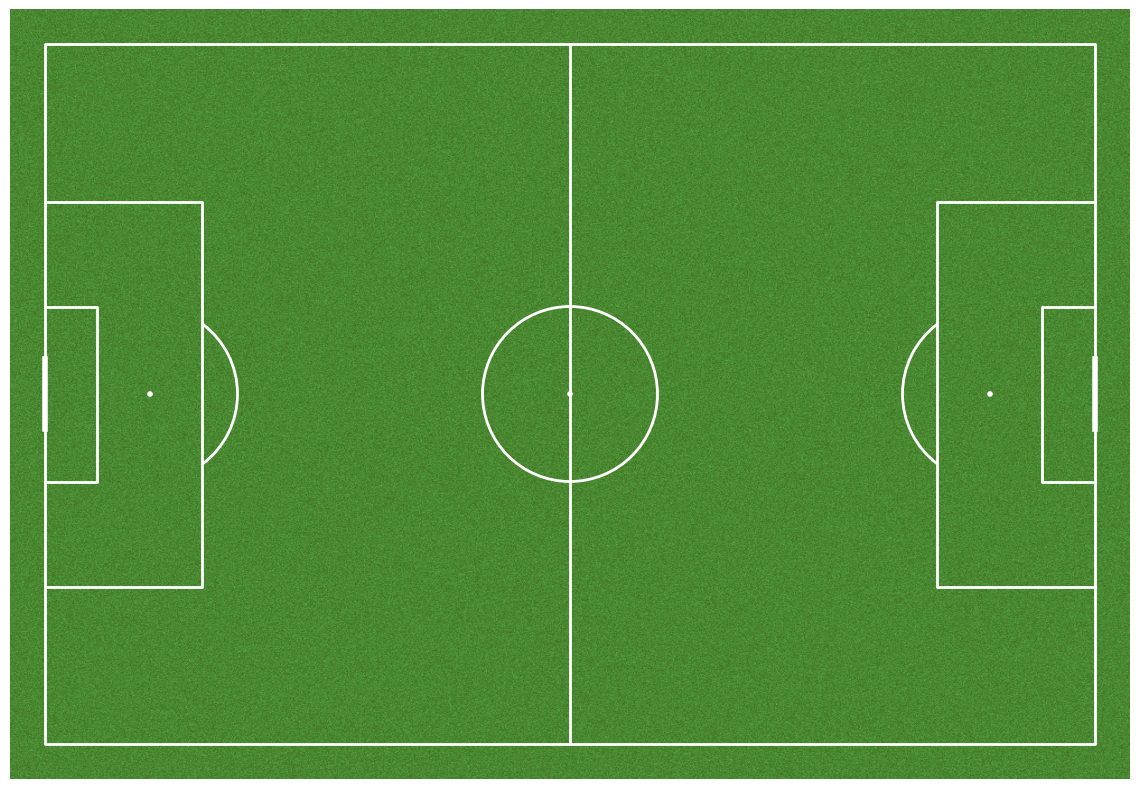

In [10]:
#Build a pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))